The goal of this project is to build a generative chatbot using the **Cornell MovieDialogs Corpus**<br> to carry out multi-turn, context-aware conversations. By leveraging the **T5 architecture**, the <br>chatbot generates coherent, movie-like responses from a dataset containing 220,579 exchanges <br>between 10,292 characters from 617 films (Danescu-Niculescu-Mizil & Lee, 2011).

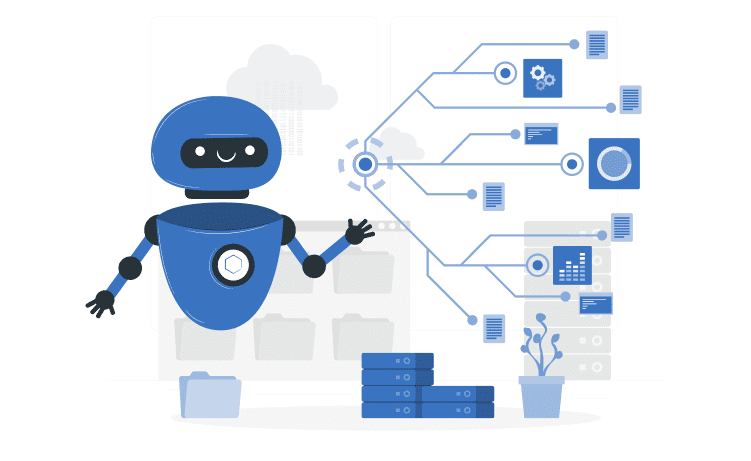
<br>(Volzna, 2024)



### Install Libraries, Import Libraries, Collect Data

In [1]:
# !pip install kaggle
# !pip install transformers torch datasets

In [2]:
# Standard Library Imports
import os
import re
import warnings
from collections import Counter

# Third-Party Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# NLTK Imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# PyTorch Imports
import torch
from torch.utils.data import DataLoader, Dataset

# Hugging Face Transformers Imports
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Suppress all warnings
warnings.filterwarnings('ignore')

In [3]:
# Download directly from Kaggle - Thai is using this 'code block' for file path
# Set Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = os.getenv('KAGGLE_USERNAME', '<your-kaggle-username>')  # Replace with your Kaggle username
os.environ['KAGGLE_KEY'] = os.getenv('KAGGLE_KEY', '<your-kaggle-api-key>')  # Replace with your Kaggle API key

# Download the dataset
!kaggle datasets download -d rajathmc/cornell-moviedialog-corpus

# Unzip the dataset (A for All and Press Enter))
!unzip cornell-moviedialog-corpus.zip

Dataset URL: https://www.kaggle.com/datasets/rajathmc/cornell-moviedialog-corpus
License(s): CC0-1.0
 84% 8.00M/9.58M [00:00<00:00, 83.1MB/s]
100% 9.58M/9.58M [00:00<00:00, 93.6MB/s]
Archive:  cornell-moviedialog-corpus.zip
  inflating: .DS_Store               
  inflating: README.txt              
  inflating: chameleons.pdf          
  inflating: movie_characters_metadata.txt  
  inflating: movie_conversations.txt  
  inflating: movie_lines.txt         
  inflating: movie_titles_metadata.txt  
  inflating: raw_script_urls.txt     


In [4]:
# List files to ensure they were extracted from kaggle
extracted_files = os.listdir()
"Extracted files:", extracted_files

('Extracted files:',
 ['.config',
  '.DS_Store',
  'raw_script_urls.txt',
  'movie_characters_metadata.txt',
  'movie_conversations.txt',
  'README.txt',
  'chameleons.pdf',
  'cornell-moviedialog-corpus.zip',
  'movie_titles_metadata.txt',
  'movie_lines.txt',
  'sample_data'])

### Load and Explore Data

In [5]:
# Individual Team member's file path

# Define the folder path
# folder_path = 'C:/MS_AAI/CornellMovie/' #Anand data path file
# folder_path = 'C:/Users/Saad/Desktop/Saad Learnings/Python/School Python/Natural Language Processing/Project/CornellMovie/' #Saad data path file
folder_path = './' # Thai data path file

In [6]:
# Initialize a dictionary to store file content
data = {}

# Loop through each file in the directory
for file_name in os.listdir(folder_path):
    if file_name.endswith('.txt'):
        file_path = os.path.join(folder_path, file_name)
        with open(file_path, 'r', encoding='utf-8', errors='replace') as file:
            content = file.readlines()  # Read each line
        data[file_name] = content

# Convert the dictionary to a DataFrame
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))

# Load completed
print("Data loaded successfully!")

Data loaded successfully!


In [7]:
print("1. Basic Information:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\n2. Data Types:")
print(df.dtypes)
print("\n3. Missing Values:")
print(df.isnull().sum())
print("\n4. Descriptive Statistics:")
display(df.describe().T)
print("\n5. Sample Data (first 5 rows):")
display(df.head())

1. Basic Information:
Number of rows: 304713
Number of columns: 6

2. Data Types:
raw_script_urls.txt              object
movie_characters_metadata.txt    object
movie_conversations.txt          object
README.txt                       object
movie_titles_metadata.txt        object
movie_lines.txt                  object
dtype: object

3. Missing Values:
raw_script_urls.txt              304096
movie_characters_metadata.txt    295678
movie_conversations.txt          221616
README.txt                       304600
movie_titles_metadata.txt        304096
movie_lines.txt                       0
dtype: int64

4. Descriptive Statistics:


,count,unique,top,freq
raw_script_urls.txt,617,617,m616 +++$+++ zulu dawn +++$+++ http://www.aell...,1
movie_characters_metadata.txt,9035,9035,u9034 +++$+++ VEREKER +++$+++ m616 +++$+++ zul...,1
movie_conversations.txt,83097,83097,u9030 +++$+++ u9034 +++$+++ m616 +++$+++ ['L66...,1
README.txt,113,85,\n,25
movie_titles_metadata.txt,617,617,m616 +++$+++ zulu dawn +++$+++ 1979 +++$+++ 6....,1
movie_lines.txt,304713,304713,L666256 +++$+++ u9034 +++$+++ m616 +++$+++ VER...,1



5. Sample Data (first 5 rows):


,raw_script_urls.txt,movie_characters_metadata.txt,movie_conversations.txt,README.txt,movie_titles_metadata.txt,movie_lines.txt
0,m0 +++$+++ 10 things i hate about you +++$+++ ...,u0 +++$+++ BIANCA +++$+++ m0 +++$+++ 10 things...,"u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L194', 'L19...",Cornell Movie-Dialogs Corpus\n,m0 +++$+++ 10 things i hate about you +++$+++ ...,L1045 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++...
1,m1 +++$+++ 1492: conquest of paradise +++$+++ ...,u1 +++$+++ BRUCE +++$+++ m0 +++$+++ 10 things ...,"u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L198', 'L19...",\n,m1 +++$+++ 1492: conquest of paradise +++$+++ ...,L1044 +++$+++ u2 +++$+++ m0 +++$+++ CAMERON ++...
2,m2 +++$+++ 15 minutes +++$+++ http://www.daily...,u2 +++$+++ CAMERON +++$+++ m0 +++$+++ 10 thing...,"u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L200', 'L20...",Distributed together with:\n,m2 +++$+++ 15 minutes +++$+++ 2001 +++$+++ 6.1...,L985 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$...
3,m3 +++$+++ 2001: a space odyssey +++$+++ http:...,u3 +++$+++ CHASTITY +++$+++ m0 +++$+++ 10 thin...,"u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L204', 'L20...",\n,m3 +++$+++ 2001: a space odyssey +++$+++ 1968 ...,L984 +++$+++ u2 +++$+++ m0 +++$+++ CAMERON +++...
4,m4 +++$+++ 48 hrs. +++$+++ http://www.awesomef...,u4 +++$+++ JOEY +++$+++ m0 +++$+++ 10 things i...,"u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L207', 'L20...","""Chameleons in imagined conversations: A new a...",m4 +++$+++ 48 hrs. +++$+++ 1982 +++$+++ 6.90 +...,L925 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$...


### Data Clean and Exploratory Data Analysis

In [8]:
# Focusing on Loading movie_lines.txt and movie_conversations.txt where we will parse the files
# lines_file = 'C:/Users/Saad/Desktop/Saad Learnings/Python/School Python/Natural Language Processing/Project/CornellMovie/movie_lines.txt'  #Saad data path file
# conversations_file = 'C:/Users/Saad/Desktop/Saad Learnings/Python/School Python/Natural Language Processing/Project/CornellMovie/movie_conversations.txt' #Saad data path file

In [9]:
# Thai used this file path for Kaggle download
lines_file = 'movie_lines.txt'
conversations_file = 'movie_conversations.txt'

In [10]:
# Function to parse movie_lines.txt
def parse_lines(lines_file):
    lines = {}
    character_names = {}
    with open(lines_file, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.split(" +++$+++ ")
            if len(parts) == 5:
                line_id = parts[0]
                character_name = parts[3]  # Extract character name
                text = parts[4].strip()
                lines[line_id] = text
                character_names[line_id] = character_name  # Store character names
    return lines, character_names


# Call the function and store the results
lines, character_names = parse_lines(lines_file)

# Construct the DataFrame
lines_df = pd.DataFrame({
    'LineID': list(lines.keys()),
    'Text': list(lines.values()),
    'CharacterName': [character_names[line_id] for line_id in lines.keys()]  # Add CharacterName
})

In [11]:
lines_df.info()  # Check for missing values and data types
lines_df.head()  # Check if the data looks correct

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304713 entries, 0 to 304712
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   LineID         304713 non-null  object
 1   Text           304713 non-null  object
 2   CharacterName  304713 non-null  object
dtypes: object(3)
memory usage: 7.0+ MB


,LineID,Text,CharacterName
0,L1045,They do not!,BIANCA
1,L1044,They do to!,CAMERON
2,L985,I hope so.,BIANCA
3,L984,She okay?,CAMERON
4,L925,Let's go.,BIANCA


In [12]:
# Function to parse movie_conversations.txt
def parse_conversations(conversations_file):
    conversations = []
    with open(conversations_file, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.split(" +++$+++ ")
            if len(parts) == 4:
                line_ids = eval(parts[3])  # This is a list of line IDs in a conversation
                conversations.append(line_ids)
    return conversations

# Call the function and store the result in the conversations variable
conversations = parse_conversations(conversations_file)

# Now you can print the conversations variable
print(conversations)

[['L194', 'L195', 'L196', 'L197'], ['L198', 'L199'], ['L200', 'L201', 'L202', 'L203'], ['L204', 'L205', 'L206'], ['L207', 'L208'], ['L271', 'L272', 'L273', 'L274', 'L275'], ['L276', 'L277'], ['L280', 'L281'], ['L363', 'L364'], ['L365', 'L366'], ['L367', 'L368'], ['L401', 'L402', 'L403'], ['L404', 'L405', 'L406', 'L407'], ['L575', 'L576'], ['L577', 'L578'], ['L662', 'L663'], ['L693', 'L694', 'L695'], ['L696', 'L697', 'L698', 'L699'], ['L860', 'L861'], ['L862', 'L863', 'L864', 'L865'], ['L866', 'L867', 'L868', 'L869'], ['L870', 'L871', 'L872'], ['L924', 'L925'], ['L984', 'L985'], ['L1044', 'L1045'], ['L49', 'L50', 'L51'], ['L571', 'L572', 'L573'], ['L579', 'L580'], ['L595', 'L596', 'L597'], ['L598', 'L599', 'L600'], ['L659', 'L660'], ['L952', 'L953'], ['L394', 'L395'], ['L396', 'L397'], ['L589', 'L590', 'L591'], ['L592', 'L593'], ['L756', 'L757', 'L758'], ['L759', 'L760'], ['L164', 'L165'], ['L319', 'L320'], ['L441', 'L442', 'L443', 'L444', 'L445'], ['L525', 'L526', 'L527'], ['L529', 'L5

In [13]:
# Function to create dialog pairs
def create_dialog_pairs(conversations, lines):
    """Create dialog pairs from conversations and line mappings."""
    dialog_pairs = []
    for conv in conversations:
        for i in range(len(conv) - 1):
            input_line = lines.get(conv[i], "")
            response_line = lines.get(conv[i + 1], "")
            if input_line and response_line:
                dialog_pairs.append((input_line, response_line))
    return dialog_pairs


# Convert lines to a dictionary and create dialog pairs
dialog_pairs = create_dialog_pairs(
    conversations, lines_df.set_index('LineID')['Text'].to_dict()
)

# Print some dialog pairs for review
for pair in dialog_pairs[:5]:
    print(f"Input: {pair[0]}\nResponse: {pair[1]}\n")

Input: Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.
Response: Well, I thought we'd start with pronunciation, if that's okay with you.

Input: Well, I thought we'd start with pronunciation, if that's okay with you.
Response: Not the hacking and gagging and spitting part.  Please.

Input: Not the hacking and gagging and spitting part.  Please.
Response: Okay... then how 'bout we try out some French cuisine.  Saturday?  Night?

Input: You're asking me out.  That's so cute. What's your name again?
Response: Forget it.

Input: No, no, it's my fault -- we didn't have a proper introduction ---
Response: Cameron.



In [14]:
# Convert dialog pairs to DataFrame for easier manipulation
cleaned_dialog_df = pd.DataFrame(dialog_pairs, columns=['input', 'response'])

# Check the first few rows of the DataFrame
cleaned_dialog_df.head()

,input,response
0,Can we make this quick? Roxanne Korrine and A...,"Well, I thought we'd start with pronunciation,..."
1,"Well, I thought we'd start with pronunciation,...",Not the hacking and gagging and spitting part....
2,Not the hacking and gagging and spitting part....,Okay... then how 'bout we try out some French ...
3,You're asking me out. That's so cute. What's ...,Forget it.
4,"No, no, it's my fault -- we didn't have a prop...",Cameron.


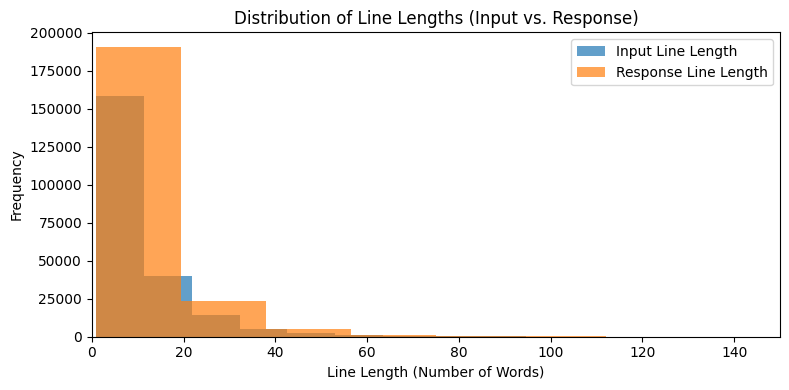

In [15]:
# Displaying Line length distribution
cleaned_dialog_df['input_length'] = cleaned_dialog_df['input'].apply(lambda x: len(x.split()))
cleaned_dialog_df['response_length'] = cleaned_dialog_df['response'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))  # Adjusted size for better PDF print compatibility
plt.hist(cleaned_dialog_df['input_length'], bins=30, alpha=0.7, label='Input Line Length')
plt.hist(cleaned_dialog_df['response_length'], bins=30, alpha=0.7, label='Response Line Length')
plt.title('Distribution of Line Lengths (Input vs. Response)')
plt.xlabel('Line Length (Number of Words)')
plt.xlim(0, 150)
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()  # Ensure everything fits within the figure bounds
plt.show()

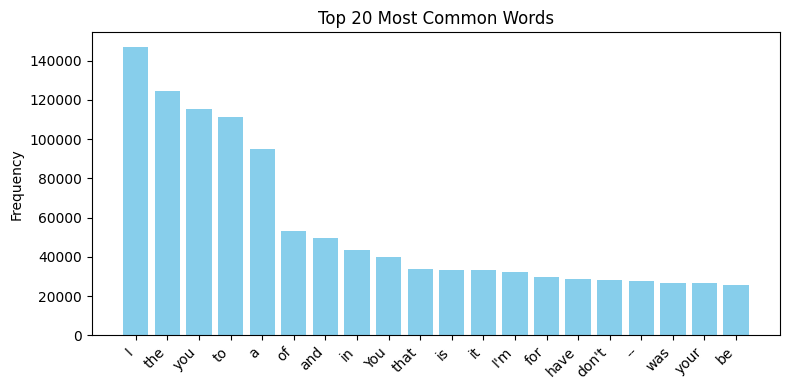

In [16]:
# Visualization of the most common words used
all_words = ' '.join(cleaned_dialog_df['input'].tolist() + cleaned_dialog_df['response'].tolist()).split()
word_counts = Counter(all_words)  # Most common words in the cleaned dialog pairs

# Top 20 most common words
common_words = word_counts.most_common(20)
words, counts = zip(*common_words)

# Plot the most common words
plt.figure(figsize=(8, 4))  # Adjust to smaller size if necessary for better printing
plt.bar(words, counts, color='skyblue')  # Use a more visible color for clarity
plt.title('Top 20 Most Common Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate and align text for readability
plt.tight_layout()  # Ensures everything fits within the figure
plt.show()

### Text Preprocessing

In [17]:
# Download required resources from nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess_text(text):
    """Lowercase, remove punctuation, tokenize, remove stopwords, and lemmatize text."""

    # 1. Lowercasing
    text = text.lower()

    # 2. Removing Punctuation and Special Characters
    text = re.sub(r'[^\w\s]', '', text)  # Removes punctuation

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Removing Stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Lemmatization (Optional but recommended)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a single string
    return ' '.join(tokens)

# Applying the preprocessing to both 'input' and 'response' columns
cleaned_dialog_df['cleaned_input'] = cleaned_dialog_df['input'].apply(preprocess_text)
cleaned_dialog_df['cleaned_response'] = cleaned_dialog_df['response'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [18]:
# Display the first few rows to check the preprocessing
print(cleaned_dialog_df[['cleaned_input', 'cleaned_response']].head())

                                       cleaned_input  \
0  make quick roxanne korrine andrew barrett incr...   
1    well thought wed start pronunciation thats okay   
2               hacking gagging spitting part please   
3                 youre asking thats cute whats name   
4                    fault didnt proper introduction   

                                  cleaned_response  
0  well thought wed start pronunciation thats okay  
1             hacking gagging spitting part please  
2      okay bout try french cuisine saturday night  
3                                           forget  
4                                          cameron  


### Additional Preprocessing Step - Handling Rare Words

In [19]:
# Step 1: Combine all text (input and response) into a single list of words
all_words = ' '.join(cleaned_dialog_df['input'].tolist() + cleaned_dialog_df['response'].tolist()).split()

# Step 2: Count the frequency of each word
word_counts = Counter(all_words)

# Step 3: Set a threshold (e.g., words that appear fewer than 5 times are considered rare)
threshold = 5
rare_words = {word for word, count in word_counts.items() if count < threshold}

# Step 4: Define a function to replace rare words with '<UNK>'
def replace_rare_words(text, rare_words_set):
    """Replace words that are below the threshold frequency with <UNK>."""
    return ' '.join([word if word not in rare_words_set else '<UNK>' for word in text.split()])

# Step 5: Apply the function to both the input and response columns
cleaned_dialog_df['input'] = cleaned_dialog_df['input'].apply(lambda x: replace_rare_words(x, rare_words))
cleaned_dialog_df['response'] = cleaned_dialog_df['response'].apply(lambda x: replace_rare_words(x, rare_words))

# Step 6: Check a few examples
print(cleaned_dialog_df[['input', 'response']].head())

                                               input  \
0  Can we make this quick? <UNK> <UNK> and Andrew...   
1  Well, I thought we'd start with <UNK> if that'...   
2  Not the hacking and gagging and spitting part....   
3  You're asking me out. That's so cute. What's y...   
4  No, no, it's my fault -- we didn't have a prop...   

                                            response  
0  Well, I thought we'd start with <UNK> if that'...  
1  Not the hacking and gagging and spitting part....  
2  Okay... then how 'bout we try out some French ...  
3                                         Forget it.  
4                                           Cameron.  


### Data Exploration and Visualization after Preprocessing

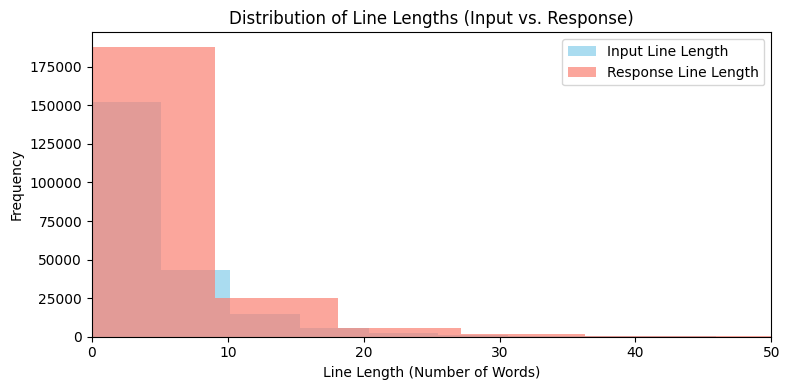

In [20]:
# 1. Distribution of Input and Response Lengths

# Calculate the length of each cleaned input and response in terms of number of words
cleaned_dialog_df['input_length'] = cleaned_dialog_df['cleaned_input'].apply(lambda x: len(x.split()))
cleaned_dialog_df['response_length'] = cleaned_dialog_df['cleaned_response'].apply(lambda x: len(x.split()))

# Plot histograms for input and response lengths
plt.figure(figsize=(8, 4))
plt.hist(cleaned_dialog_df['input_length'], bins=30, alpha=0.7, label='Input Line Length', color='skyblue')
plt.hist(cleaned_dialog_df['response_length'], bins=30, alpha=0.7, label='Response Line Length', color='salmon')
plt.title('Distribution of Line Lengths (Input vs. Response)')
plt.xlabel('Line Length (Number of Words)')
plt.xlim(0, 50)
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()  # Ensures everything fits nicely in the figure
plt.show()

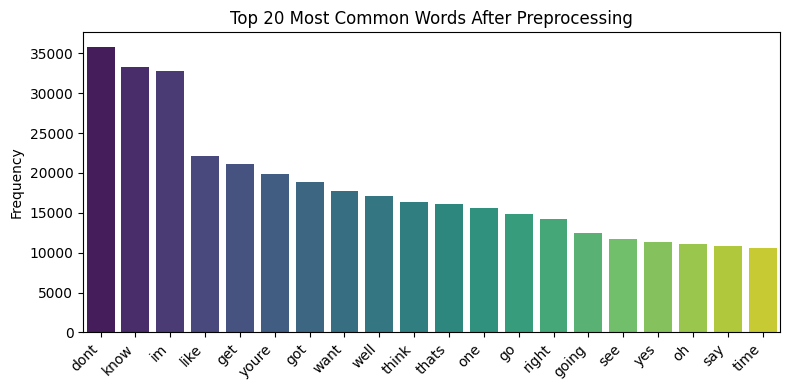

In [21]:
# 2. Most Common Words in Cleaned Input and Responses

# Combine all words from both input and response
all_words = ' '.join(cleaned_dialog_df['cleaned_input'].tolist() + cleaned_dialog_df['cleaned_response'].tolist()).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Get the 20 most common words
common_words = word_counts.most_common(20)
words, counts = zip(*common_words)

# Create a bar plot for the 20 most common words
plt.figure(figsize=(8, 4))
sns.barplot(x=list(words), y=list(counts), palette='viridis')
plt.title('Top 20 Most Common Words After Preprocessing')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Align the labels for better readability
plt.tight_layout()  # Ensure that the layout fits within the figure boundaries
plt.show()

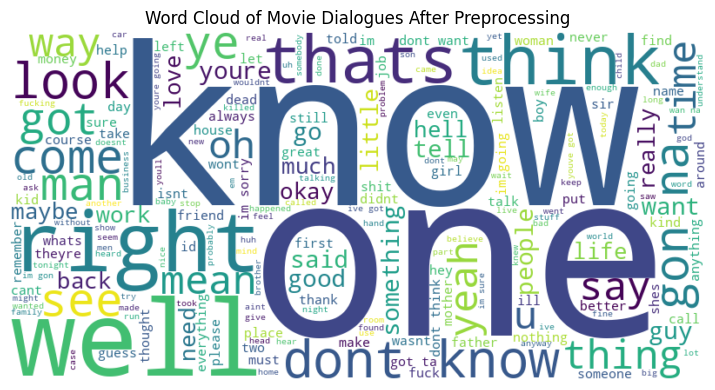

In [22]:
# 3. Word Cloud of Most Common Words

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))

# Display the word cloud
plt.figure(figsize=(10, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title("Word Cloud of Movie Dialogues After Preprocessing")
plt.tight_layout()  # Ensure the layout fits within the figure boundaries
plt.show()

Average Input Length (in words): 5.18
Average Response Length (in words): 5.38


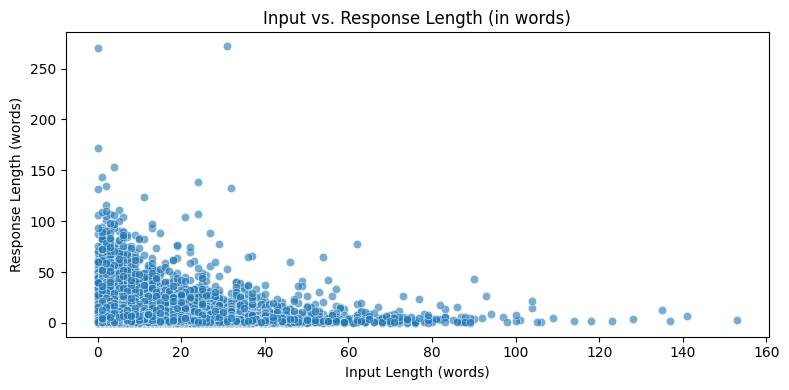

In [23]:
# 4. Statistics: Average Input and Response Length

# Calculate average input and response length
avg_input_length = cleaned_dialog_df['input_length'].mean()
avg_response_length = cleaned_dialog_df['response_length'].mean()

print(f"Average Input Length (in words): {avg_input_length:.2f}")
print(f"Average Response Length (in words): {avg_response_length:.2f}")

# Optional: Visualizing Input vs Response Length
plt.figure(figsize=(8, 4))
sns.scatterplot(x='input_length', y='response_length', data=cleaned_dialog_df, alpha=0.6)
plt.title('Input vs. Response Length (in words)')
plt.xlabel('Input Length (words)')
plt.ylabel('Response Length (words)')
plt.tight_layout()  # Ensure the layout fits within the figure
plt.show()

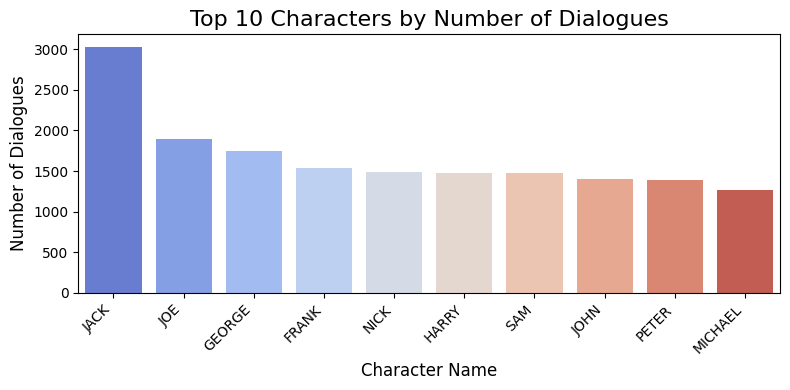

In [24]:
# Assuming 'lines_df' is the DataFrame with the 'CharacterName' column
# Count the number of lines spoken by each character
top_characters = lines_df['CharacterName'].value_counts().head(10)

# Plot the top 10 characters by the number of lines spoken
plt.figure(figsize=(8, 4))
sns.barplot(x=top_characters.index, y=top_characters.values, palette='coolwarm')
plt.title("Top 10 Characters by Number of Dialogues", fontsize=16)
plt.xlabel("Character Name", fontsize=12)
plt.ylabel("Number of Dialogues", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels and align them for better readability
plt.tight_layout()  # Ensure layout fits within the figure
plt.show()

The visuals **after preprocessing** provide insights into the cleaned dataset. The first histogram shows the <br>distribution of **line lengths** for both input and response dialogues, indicating that most conversations are <br>short, with the majority being under 10 words. The bar chart of the **top 20 most common words** reveals <br>frequent usage of conversational terms like "don't," "know," and "I'm," illustrating common speech patterns <br>in movie dialogues. The **word cloud** highlights key dialogue words after preprocessing, showcasing <br>prominent terms such as "know," "one," and "well." The **scatter plot**, comparing input and response lengths,<br> indicates a positive correlation where longer inputs tend to produce longer responses. Lastly, the bar chart<br> displaying the **top 10 characters** by the number of dialogues reveals "Jack" as the most frequent speaker, <br>followed by "Joe" and "George." Together, these visuals demonstrate how the dataset has been effectively <br>cleaned and analyzed for key conversational patterns.

### Check for Imbalance in the Data

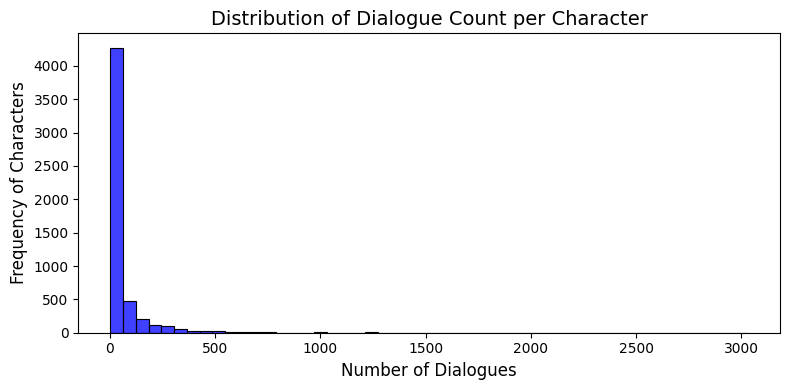

count    5356.000000
mean       56.891897
std       133.209117
min         3.000000
25%         6.000000
50%        15.000000
75%        48.000000
max      3032.000000
Name: count, dtype: float64


In [25]:
# Check for imbalance in character dialogue count
character_dialogue_counts = lines_df['CharacterName'].value_counts()

# Visualize the distribution
plt.figure(figsize=(8, 4))
sns.histplot(character_dialogue_counts, kde=False, bins=50, color='blue')
plt.title('Distribution of Dialogue Count per Character', fontsize=14)
plt.xlabel('Number of Dialogues', fontsize=12)
plt.ylabel('Frequency of Characters', fontsize=12)
plt.tight_layout()  # Ensure layout fits within the figure
plt.show()

# Identify any imbalances (characters with significantly more dialogues)
print(character_dialogue_counts.describe())

The **bar chart above** shows the distribution of dialogue counts per character in the dataset, with most characters <br>contributing fewer than 500 lines and a significant majority speaking under 100 lines. Addressing this imbalance<br> could enhance response diversity by including less frequent characters, but it's not essential unless broader <br>character representation is desired.

### Split the Data

In [26]:
# Split the data into training, validation, and test sets
train_data, temp_data = train_test_split(cleaned_dialog_df, test_size=0.2, random_state=42)  # 80% training
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)  # 10% validation, 10% test

# Display the sizes of each set
print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

Training set size: 177025
Validation set size: 22128
Test set size: 22129


## Implement T5 Model
### Setup Tokenizer

In [27]:
# Load T5 tokenizer and model
tokenizer = T5Tokenizer.from_pretrained('t5-small')  # You can also use 't5-base' or 't5-large'
model = T5ForConditionalGeneration.from_pretrained('t5-small')

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Check if CUDA (GPU) is available
torch.cuda.is_available()

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

True

### Modify Dataset Class for T5

In [28]:
class DialogDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=512):
        """Initialize the dataset with data, tokenizer, and max_length."""
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """Return the total number of samples."""
        return len(self.data)

    def __getitem__(self, idx):
        """Retrieve the tokenized input and response for the given index."""
        input_text = self.data.iloc[idx]['cleaned_input']
        response_text = self.data.iloc[idx]['cleaned_response']

        # Prepare the text-to-text task in T5 format
        input_text = f"dialogue: {input_text} </s>"
        response_text = f"{response_text} </s>"

        # Tokenize inputs and responses
        input_ids = self.tokenizer.encode(
            input_text,
            return_tensors='pt',
            max_length=self.max_length,
            padding='max_length',
            truncation=True
        )
        target_ids = self.tokenizer.encode(
            response_text,
            return_tensors='pt',
            max_length=self.max_length,
            padding='max_length',
            truncation=True
        )

        return input_ids.squeeze(), target_ids.squeeze()

In [29]:
class ConversationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, source_len, target_len):
        """Initialize the dataset with dataframe, tokenizer, source and target lengths."""
        self.tokenizer = tokenizer
        self.data = dataframe
        self.source_len = source_len
        self.target_len = target_len
        self.input_text = self.data.input
        self.target_text = self.data.response

    def __len__(self):
        """Return the total number of samples."""
        return len(self.input_text)

    def __getitem__(self, index):
        """Retrieve and encode the input and target text at the given index."""
        # Encode inputs and outputs using the T5 tokenizer
        source_text = str(self.input_text[index])
        target_text = str(self.target_text[index])

        # Tokenize input text
        source = self.tokenizer.batch_encode_plus(
            [source_text],
            max_length=self.source_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        # Tokenize target text
        target = self.tokenizer.batch_encode_plus(
            [target_text],
            max_length=self.target_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        source_ids = source["input_ids"].squeeze()
        source_mask = source["attention_mask"].squeeze()
        target_ids = target["input_ids"].squeeze()

        return {
            "input_ids": source_ids,
            "attention_mask": source_mask,
            "labels": target_ids
        }

### Create DataLoader for Training and Validation

In [30]:
# Split dataset into training and validation sets
train_size = int(0.8 * len(cleaned_dialog_df))
val_size = len(cleaned_dialog_df) - train_size

# Create the training and validation datasets
train_dataset = DialogDataset(train_data, tokenizer=tokenizer, max_length=50)
val_dataset = DialogDataset(val_data, tokenizer=tokenizer, max_length=50)

# Create DataLoaders for the training and validation sets
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

### Model Training

In [31]:
# Define optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Training loop
num_epochs = 20

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    total_loss = 0

    # Loop through the training data
    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{num_epochs}"):
        input_ids = batch[0].to(device)
        labels = batch[1].to(device)

        # Generate attention mask based on input_ids
        attention_mask = (input_ids != tokenizer.pad_token_id).long().to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{num_epochs}, Average Training Loss: {avg_train_loss:.4f}")

Training Epoch 1/20: 100%|██████████| 11065/11065 [11:28<00:00, 16.08it/s]


Epoch 1/20, Average Training Loss: 0.9105


Training Epoch 2/20: 100%|██████████| 11065/11065 [11:28<00:00, 16.08it/s]


Epoch 2/20, Average Training Loss: 0.8435


Training Epoch 3/20: 100%|██████████| 11065/11065 [11:28<00:00, 16.06it/s]


...

Epoch 18/20, Average Training Loss: 0.7439


Training Epoch 19/20: 100%|██████████| 11065/11065 [11:29<00:00, 16.05it/s]


Epoch 19/20, Average Training Loss: 0.7400


Training Epoch 20/20: 100%|██████████| 11065/11065 [11:29<00:00, 16.06it/s]

Epoch 20/20, Average Training Loss: 0.7360


In [32]:
# Save the trained model and tokenizer
model_dir = 'models/t5_chatbot_final'

# Save model and tokenizer to the specified directory
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

('models/t5_chatbot_final/tokenizer_config.json',
 'models/t5_chatbot_final/special_tokens_map.json',
 'models/t5_chatbot_final/spiece.model',
 'models/t5_chatbot_final/added_tokens.json')

### Model Evaluation

In [33]:
# Function to evaluate model and print metrics
def evaluate_model(model, dataloader, device):
    """Evaluate the model on the given dataloader and return loss and predictions."""
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    all_predictions = []
    all_targets = []

    with torch.no_grad():  # Disable gradient calculation for evaluation
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids, target_ids = batch
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, labels=target_ids)
            val_loss = outputs.loss

            total_loss += val_loss.item()

            # Collect predictions and targets for metrics calculation
            predicted_ids = torch.argmax(outputs.logits, dim=-1).cpu().numpy().flatten()
            all_predictions.extend(predicted_ids)
            all_targets.extend(target_ids.cpu().numpy().flatten())

    avg_loss = total_loss / len(dataloader)
    return avg_loss, all_predictions, all_targets


# Evaluate model on validation data after training
val_loss, val_predictions, val_targets = evaluate_model(model, val_loader, device)
print(f"Validation Loss: {val_loss:.4f}")

Evaluating: 100%|██████████| 1383/1383 [00:38<00:00, 36.27it/s]

Validation Loss: 1.0251


### Model Metrics

In [34]:
# Calculate and print evaluation metrics
accuracy = accuracy_score(val_targets, val_predictions)
precision = precision_score(val_targets, val_predictions, average='weighted')
recall = recall_score(val_targets, val_predictions, average='weighted')
f1 = f1_score(val_targets, val_predictions, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8704
Precision: 0.8418
Recall: 0.8704
F1-Score: 0.8490


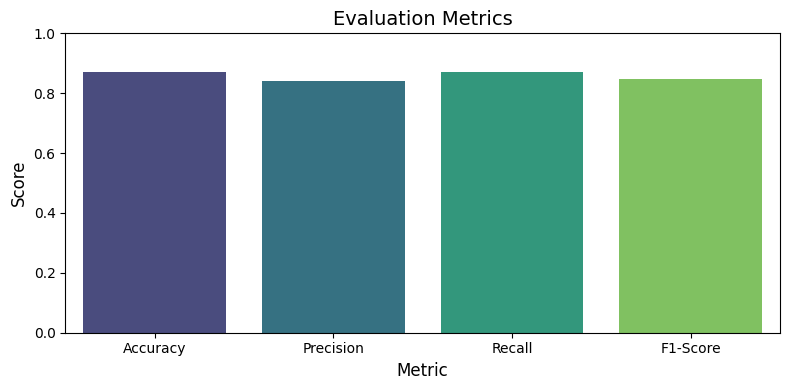

In [35]:
# Visualizing the Metrics
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
metrics_names = list(metrics.keys())
metrics_values = list(metrics.values())

plt.figure(figsize=(8, 4))
sns.barplot(x=metrics_names, y=metrics_values, palette='viridis')
plt.title("Evaluation Metrics", fontsize=14)
plt.ylim(0, 1)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()  # Ensures everything fits within the figure
plt.show()

In [38]:
# Import the necessary libraries
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load the pre-trained T5 model and tokenizer (you can load your fine-tuned model here)
model_name = 'models/t5_chatbot_final'
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Move the model to the appropriate device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

def generate_response(conversation_history):
    """Generate a chatbot response based on the conversation history."""
    # Concatenate conversation history for context
    input_text = " ".join(conversation_history)

    # Tokenize and encode the input text
    input_ids = tokenizer.encode(f"dialogue: {input_text}", return_tensors="pt").to(device)  # Move to correct device

    # Generate the output using the model
    output_ids = model.generate(input_ids, max_length=50, num_beams=4, early_stopping=True)

    # Decode the output into a human-readable response
    response = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    return response

# Interactive chatbot loop to converse with the user
if __name__ == "__main__":
    while True:
        user_input = input("You: ")
        if user_input.lower() == "exit":
            print("Chatbot: Goodbye!")
            break
        chatbot_response = generate_response([user_input])
        print(f"Chatbot: {chatbot_response}")

You: Hi, how are you?
Chatbot: oh yeah
You: Can you tell me a little about yourself?
Chatbot: oh
You: What's your favorite movie?
Chatbot: whats favorite movie
You: Why do people fall in love?
Chatbot: oh god
You: What's your favorite type of food?
Chatbot: oh
You: Can you tell me a good movie?
Chatbot: good movie
You: tell me a joke
Chatbot: uhhuh
You: Who is the best movie character?
Chatbot: oh
You: Do you believe?
Chatbot: dont believe
You: Who is your mother?
Chatbot: dont know
You: exit
Chatbot: Goodbye!


## References<br>
Danescu-Niculescu-Mizil, C., & Lee, L. (2011). *Cornell movie-dialogs corpus.* Cornell <br>University. https://www.cs.cornell.edu/~cristian/Cornell_Movie-Dialogs_Corpus.html

Vozna, A. (2024, June 13). *AI chatbot development: A complete guide.<br>* https://gloriumtech.com/ai-chatbot-development-a-complete-guide/